In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("netflix_cleaned.csv")
df = df.loc[:,~df.columns.str.contains('^Unnamed')]


# Display first 5 rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


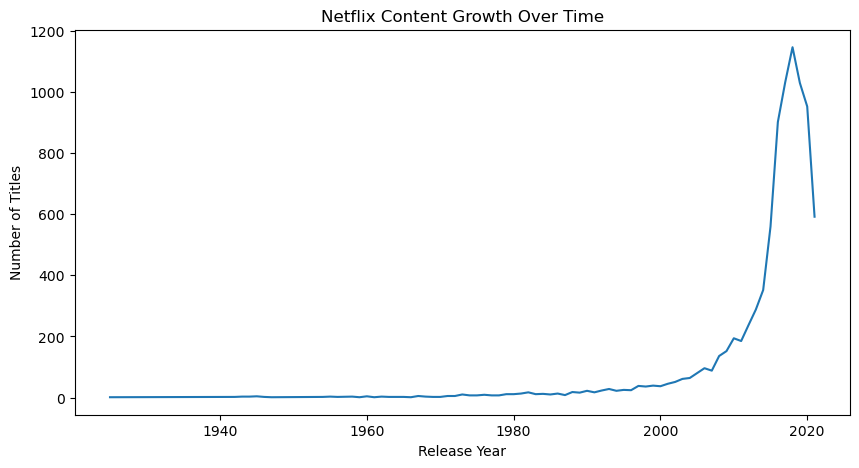

In [24]:
plt.figure(figsize=(10,5))
df['release_year'].value_counts().sort_index().plot(kind='line')
plt.title('Netflix Content Growth Over Time')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.show()

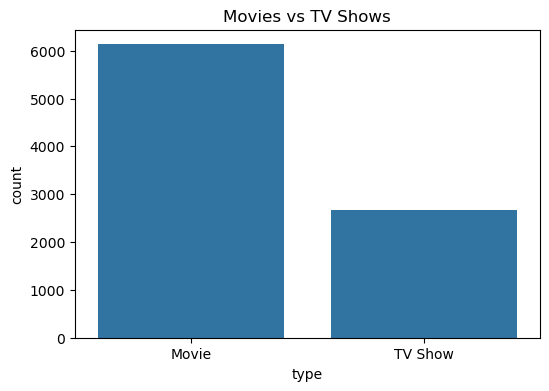

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [25]:
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df)
plt.title('Movies vs TV Shows')
plt.show()

print(df['type'].value_counts())

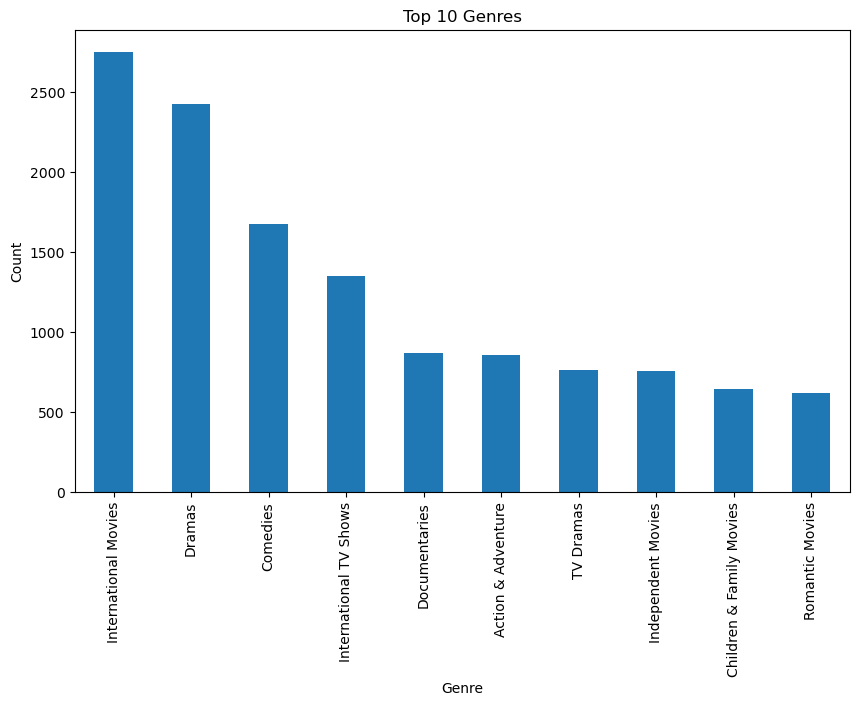

In [26]:
genres = df['listed_in'].str.split(', ', expand=True).stack()

plt.figure(figsize=(10,6))
genres.value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.show()

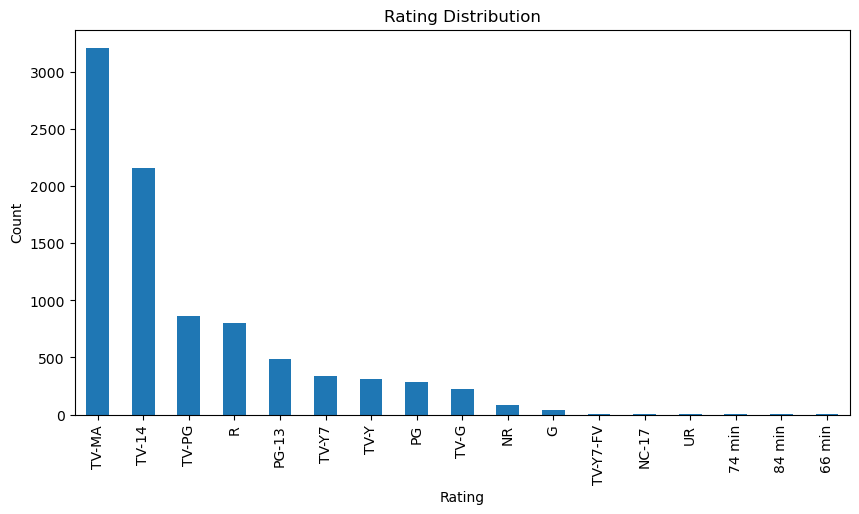

In [28]:
plt.figure(figsize=(10,5))
df['rating'].value_counts().plot(kind='bar')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

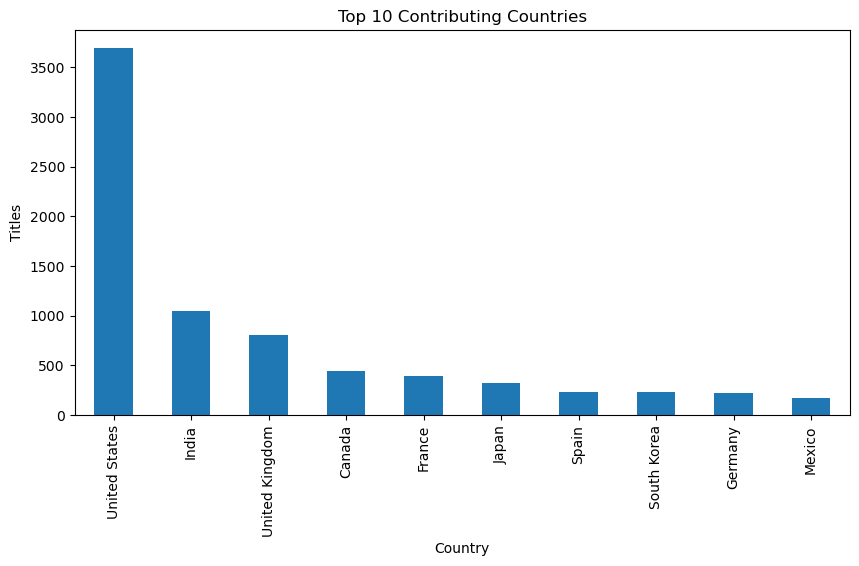

United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


In [29]:
countries = df['country'].dropna().str.split(', ', expand=True).stack()

plt.figure(figsize=(10,5))
countries.value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Contributing Countries')
plt.xlabel('Country')
plt.ylabel('Titles')
plt.show()

print(countries.value_counts().head(10))

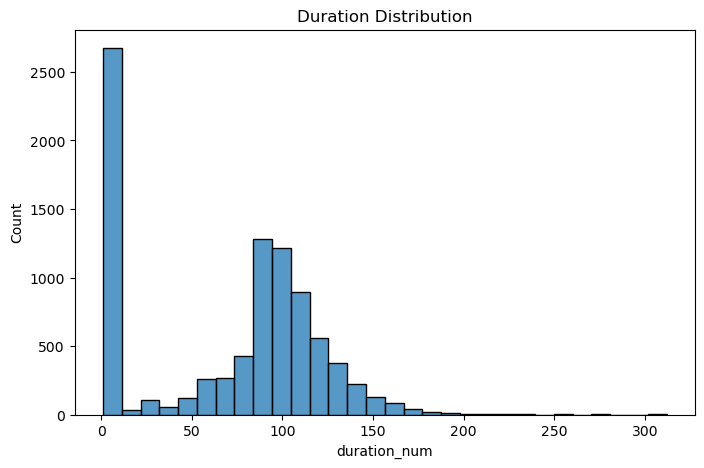

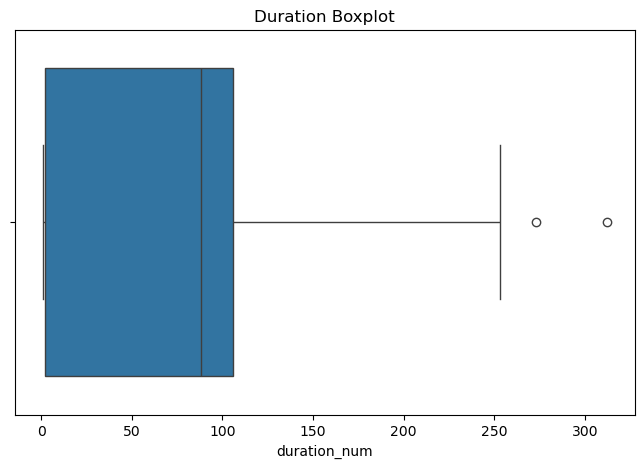

In [30]:
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)

plt.figure(figsize=(8,5))
sns.histplot(df['duration_num'], bins=30)
plt.title('Duration Distribution')
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x=df['duration_num'])
plt.title('Duration Boxplot')
plt.show()

In [31]:
def length_category(x):
    if x < 60:
        return "Short"
    elif x <= 120:
        return "Medium"
    else:
        return "Long"

df['content_length_category'] = df['duration_num'].apply(length_category)

print(df[['duration_num','content_length_category']].head())

   duration_num content_length_category
0          90.0                  Medium
1           2.0                   Short
2           1.0                   Short
3           1.0                   Short
4           2.0                   Short


In [32]:
current_year = 2026

df['content_age'] = current_year - df['release_year']

print(df[['release_year','content_age']].head())

   release_year  content_age
0          2020            6
1          2021            5
2          2021            5
3          2021            5
4          2021            5


In [33]:
df['decade'] = (df['release_year']//10)*10
df['decade'] = df['decade'].astype(str) + 's'

print(df[['release_year','decade']].head())

   release_year decade
0          2020  2020s
1          2021  2020s
2          2021  2020s
3          2021  2020s
4          2021  2020s


In [34]:
df['genre_count'] = df['listed_in'].apply(lambda x: len(str(x).split(',')))

print(df[['listed_in','genre_count']].head())

                                           listed_in  genre_count
0                                      Documentaries            1
1    International TV Shows, TV Dramas, TV Mysteries            3
2  Crime TV Shows, International TV Shows, TV Act...            3
3                             Docuseries, Reality TV            2
4  International TV Shows, Romantic TV Shows, TV ...            3


In [35]:
df.to_csv("netflix_featured.csv", index=False)

print("Feature Engineered Dataset Saved Successfully!")

Feature Engineered Dataset Saved Successfully!


In [36]:
df = pd.read_csv("netflix_featured.csv")
print(df[['content_length_category',
          'content_age',
          'decade',
          'genre_count']].head())

  content_length_category  content_age decade  genre_count
0                  Medium            6  2020s            1
1                   Short            5  2020s            3
2                   Short            5  2020s            3
3                   Short            5  2020s            2
4                   Short            5  2020s            3
